## 1. Import Libraries

In [28]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Static visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Interactive visualization (used selectively, where hover/zoom adds real value —
import plotly.express as px
import plotly.graph_objects as go

# --- Stats (for categorical association / Cramer's V, missingness, etc.) ---
from scipy import stats
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

# --- Global display / plotting settings ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded.")


Libraries loaded.


## 2. Load Both Datasets

In [29]:
# File paths — update these if your files live elsewhere
ACCIDENT_PATH = "/Users/kartik/Desktop/SaiKiran/Projects/road_accident_severity_prediction_and_hotspot_analysis/data/Accident_Information.csv"
VEHICLE_PATH = "/Users/kartik/Desktop/SaiKiran/Projects/road_accident_severity_prediction_and_hotspot_analysis/data/Vehicle_Information.csv"

def load_csv(path, name):
    """Load a CSV with settings tuned for this dataset's known quirks, and report basic load stats."""
    df = pd.read_csv(path, encoding="latin1", low_memory=False)
    print(f"[{name}] Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns "
          f"| Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    return df

df_accident = load_csv(ACCIDENT_PATH, "Accident_Information")
df_vehicle = load_csv(VEHICLE_PATH, "Vehicle_Information")


[Accident_Information] Loaded: 2,047,256 rows x 34 columns | Memory: 2650.9 MB
[Vehicle_Information] Loaded: 2,177,205 rows x 24 columns | Memory: 2359.7 MB


## 3. Dataset Shape

In [30]:
shape_summary = pd.DataFrame({
    "Dataset": ["Accident_Information", "Vehicle_Information"],
    "Rows": [df_accident.shape[0], df_vehicle.shape[0]],
    "Columns": [df_accident.shape[1], df_vehicle.shape[1]]
})
shape_summary


,Dataset,Rows,Columns
0,Accident_Information,2047256,34
1,Vehicle_Information,2177205,24


## 4. First 5 Rows

In [31]:
df_accident.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,Longitude,LSOA_of_Accident_Location,Number_of_Casualties,Number_of_Vehicles,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.489096,Daylight,Kensington and Chelsea,Kensington and Chelsea,525680.0,178240.0,-0.191170,E01002849,1,1,0.0,1.0,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,Auto traffic signal,Crossroads,51.520075,Darkness - lights lit,Kensington and Chelsea,Kensington and Chelsea,524170.0,181650.0,-0.211708,E01002909,1,1,0.0,5.0,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.525301,Darkness - lights lit,Kensington and Chelsea,Kensington and Chelsea,524520.0,182240.0,-0.206458,E01002857,1,2,0.0,0.0,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.482442,Daylight,Kensington and Chelsea,Kensington and Chelsea,526900.0,177530.0,-0.173862,E01002840,1,1,0.0,0.0,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.495752,Darkness - lighting unknown,Kensington and Chelsea,Kensington and Chelsea,528060.0,179040.0,-0.156618,E01002863,1,1,0.0,0.0,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [32]:
df_vehicle.head()

,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,make,model,Propulsion_Code,Sex_of_Driver,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
0,200401BS00001,26 - 35,3.0,Urban area,4.0,1588.0,NaN,NaN,Data missing or out of range,Data missing or out of range,ROVER,45 CLASSIC 16V,Petrol,Male,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
1,200401BS00002,26 - 35,NaN,Urban area,3.0,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,BMW,C1,NaN,Male,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,109,Data missing or out of range,Front,2004
2,200401BS00003,26 - 35,4.0,Data missing or out of range,NaN,998.0,NaN,NaN,Data missing or out of range,Data missing or out of range,NISSAN,MICRA CELEBRATION 16V,Petrol,Male,NaN,No tow/articulation,Did not leave carriageway,0.0,Turning right,1,109,Data missing or out of range,Front,2004
3,200401BS00003,66 - 75,NaN,Data missing or out of range,NaN,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,LONDON TAXIS INT,TXII GOLD AUTO,NaN,Male,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
4,200401BS00004,26 - 35,1.0,Urban area,4.0,124.0,NaN,NaN,Data missing or out of range,Data missing or out of range,PIAGGIO,VESPA ET4,Petrol,Male,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Motorcycle 125cc and under,Data missing or out of range,Front,2004


## 5. Last 5 Rows

In [33]:
df_accident.tail()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,Longitude,LSOA_of_Accident_Location,Number_of_Casualties,Number_of_Vehicles,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
2047251,2017984121017,A(M),74.0,NaN,0.0,Slight,NaN,2017-12-17,Sunday,1.0,Data missing or out of range,Not at junction or within 20 metres,55.311793,Daylight,Dumfries and Galloway,Dumfries & Galloway,308024.0,602926.0,-3.450645,NaN,1,1,0.0,0.0,Dumfries and Galloway,Frost or ice,Dual carriageway,NaN,70.0,11:30,Rural,Other,2017,Yes
2047252,2017984121217,C,69.0,NaN,0.0,Slight,Pedestrian in carriageway - not injured,2017-12-15,Friday,2.0,Data missing or out of range,Not at junction or within 20 metres,54.994285,Daylight,Dumfries and Galloway,Dumfries & Galloway,331826.0,567154.0,-3.067116,NaN,1,1,0.0,0.0,Dumfries and Galloway,Dry,Single carriageway,NaN,20.0,13:00,Urban,Fine no high winds,2017,Yes
2047253,2017984121717,A(M),74.0,Unclassified,0.0,Slight,NaN,2017-12-18,Monday,1.0,Give way or uncontrolled,Slip road,55.053767,Daylight,Dumfries and Galloway,Dumfries & Galloway,321809.0,573939.0,-3.225506,NaN,1,2,0.0,0.0,Dumfries and Galloway,Wet or damp,Dual carriageway,NaN,70.0,13:30,Rural,Fine no high winds,2017,Yes
2047254,2017984122317,A,708.0,NaN,0.0,Slight,NaN,2017-07-18,Tuesday,1.0,Data missing or out of range,Not at junction or within 20 metres,55.326392,Daylight,Dumfries and Galloway,Dumfries & Galloway,310467.0,604501.0,-3.412672,NaN,1,1,0.0,0.0,Dumfries and Galloway,Dry,Single carriageway,NaN,60.0,18:00,Rural,Fine no high winds,2017,Yes
2047255,2017984122617,B,721.0,B,724.0,Serious,NaN,2017-12-20,Wednesday,1.0,Give way or uncontrolled,T or staggered junction,54.989905,Daylight,Dumfries and Galloway,Dumfries & Galloway,318705.0,566886.0,-3.272073,NaN,2,2,0.0,0.0,Dumfries and Galloway,Wet or damp,Single carriageway,NaN,40.0,13:00,Rural,Fog or mist,2017,Yes


In [34]:
df_vehicle.tail()


,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,make,model,Propulsion_Code,Sex_of_Driver,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
2177200,2016984131116,21 - 25,14.0,Urban area,NaN,1598.0,NaN,NaN,Not known,Mid Junction - on roundabout or on main road,MINI,MINI COOPER,Petrol,Female,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Car,No,Front,2016
2177201,2016984131116,56 - 65,NaN,Small town,NaN,1598.0,NaN,NaN,Commuting to/from work,Mid Junction - on roundabout or on main road,VAUXHALL,ASTRA ENERGY CDTI,Heavy oil,Female,NaN,No tow/articulation,Offside,0.0,Going ahead other,2,Car,No,Front,2016
2177202,2016984131216,56 - 65,NaN,Urban area,3.0,NaN,NaN,Central crash barrier,Journey as part of work,Not at or within 20 metres of junction,NaN,NaN,NaN,Male,NaN,No tow/articulation,Offside on to central reservation,0.0,Going ahead other,1,Goods 7.5 tonnes mgw and over,No,Offside,2016
2177203,2016984131316,16 - 20,13.0,Urban area,6.0,1796.0,NaN,Tree,Not known,Not at or within 20 metres of junction,VAUXHALL,VECTRA SXI 16V,Petrol,Male,Skidded,No tow/articulation,Offside,0.0,Going ahead other,1,Car,No,Front,2016
2177204,2016984133416,46 - 55,5.0,Urban area,NaN,2184.0,NaN,Wall or fence,Not known,Not at or within 20 metres of junction,MAZDA,CX-7 SPORT TECH D,Heavy oil,Male,Skidded and overturned,No tow/articulation,Nearside,0.0,Going ahead other,1,Car,No,Nearside,2016


## 6. Data Types

In [35]:
def dtype_summary(df, name):
    summary = pd.DataFrame({
        "Column": df.columns,
        "Dtype": df.dtypes.astype(str).values,
        "Non-Null Count": df.notnull().sum().values,
        "Null Count": df.isnull().sum().values
    })
    print(f"--- {name}: dtype counts ---")
    print(df.dtypes.value_counts())
    return summary

dtype_accident = dtype_summary(df_accident, "Accident_Information")
dtype_vehicle = dtype_summary(df_vehicle, "Vehicle_Information")
dtype_accident

--- Accident_Information: dtype counts ---
object     21
float64    10
int64       3
Name: count, dtype: int64
--- Vehicle_Information: dtype counts ---
object     18
float64     4
int64       2
Name: count, dtype: int64


,Column,Dtype,Non-Null Count,Null Count
0,Accident_Index,object,2047256,0
1,1st_Road_Class,object,2047256,0
2,1st_Road_Number,float64,2047254,2
3,2nd_Road_Class,object,1202984,844272
4,2nd_Road_Number,float64,2029663,17593
5,Accident_Severity,object,2047256,0
6,Carriageway_Hazards,object,39449,2007807
7,Date,object,2047256,0
8,Day_of_Week,object,2047256,0
9,Did_Police_Officer_Attend_Scene_of_Accident,float64,2046978,278


In [36]:
dtype_vehicle

,Column,Dtype,Non-Null Count,Null Count
0,Accident_Index,object,2177205,0
1,Age_Band_of_Driver,object,2177205,0
2,Age_of_Vehicle,float64,1819056,358149
3,Driver_Home_Area_Type,object,2177205,0
4,Driver_IMD_Decile,float64,1442393,734812
5,Engine_Capacity_.CC.,float64,1911344,265861
6,Hit_Object_in_Carriageway,object,89381,2087824
7,Hit_Object_off_Carriageway,object,187464,1989741
8,Journey_Purpose_of_Driver,object,2177205,0
9,Junction_Location,object,2177205,0


## 7. Missing Values

In [37]:
def missing_report(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_pct
    }).sort_values("Missing %", ascending=False)
    report = report[report["Missing Count"] > 0]
    print(f"--- {name}: {len(report)} columns have missing values ---")
    return report

missing_accident = missing_report(df_accident, "Accident_Information")
missing_vehicle = missing_report(df_vehicle, "Vehicle_Information")
missing_accident

--- Accident_Information: 16 columns have missing values ---
--- Vehicle_Information: 10 columns have missing values ---


,Missing Count,Missing %
Carriageway_Hazards,2007807,98.07
Special_Conditions_at_Site,1995137,97.45
2nd_Road_Class,844272,41.24
LSOA_of_Accident_Location,144953,7.08
2nd_Road_Number,17593,0.86
Pedestrian_Crossing-Physical_Facilities,3560,0.17
Pedestrian_Crossing-Human_Control,2920,0.14
Longitude,175,0.01
Location_Easting_OSGR,164,0.01
Latitude,174,0.01


In [38]:
missing_vehicle

,Missing Count,Missing %
Hit_Object_in_Carriageway,2087824,95.89
Hit_Object_off_Carriageway,1989741,91.39
Skidding_and_Overturning,1898208,87.19
Driver_IMD_Decile,734812,33.75
Age_of_Vehicle,358149,16.45
model,325331,14.94
Engine_Capacity_.CC.,265861,12.21
Propulsion_Code,245843,11.29
make,110845,5.09
Vehicle_Location.Restricted_Lane,1317,0.06


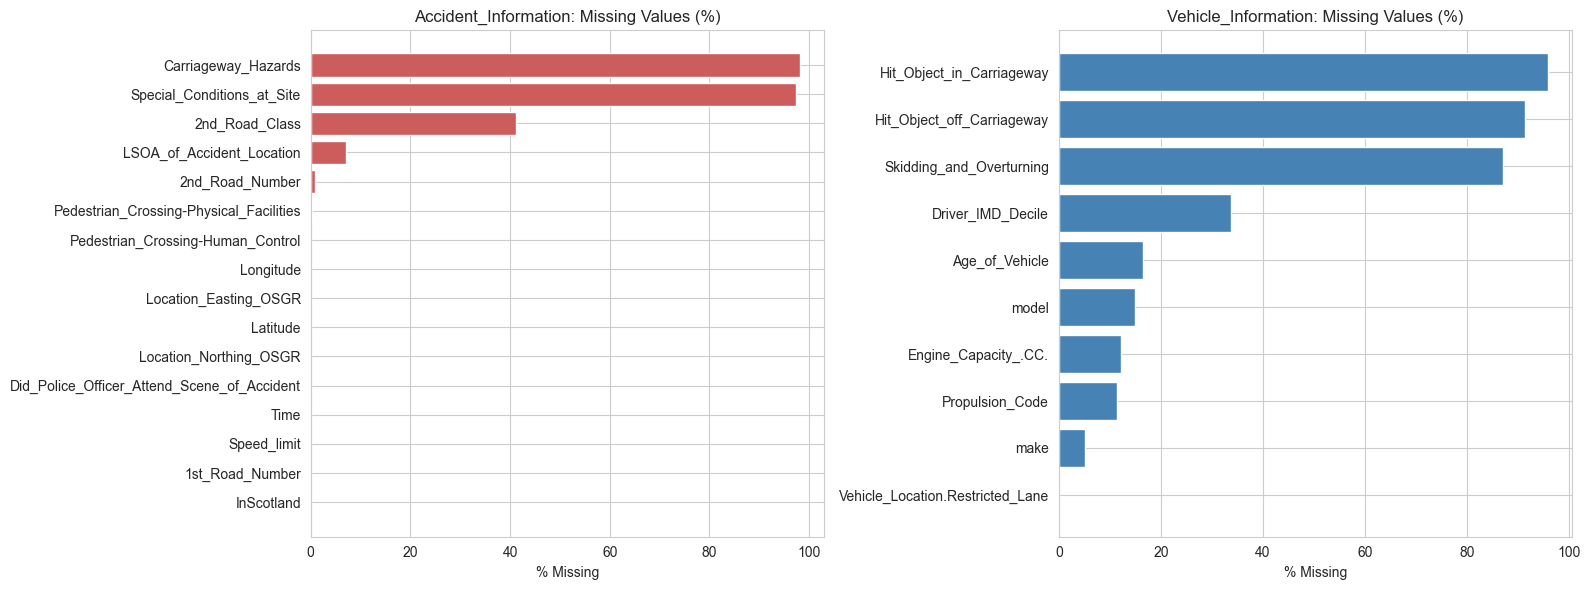

In [39]:
# Visualize missingness — bar chart is more legible than a heatmap once column count is high,
# and we only plot columns that actually have missing values.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(missing_accident) > 0:
    axes[0].barh(missing_accident.index, missing_accident["Missing %"], color="indianred")
    axes[0].set_title("Accident_Information: Missing Values (%)")
    axes[0].set_xlabel("% Missing")
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, "No missing values", ha="center")

if len(missing_vehicle) > 0:
    axes[1].barh(missing_vehicle.index, missing_vehicle["Missing %"], color="steelblue")
    axes[1].set_title("Vehicle_Information: Missing Values (%)")
    axes[1].set_xlabel("% Missing")
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center")

plt.tight_layout()
plt.show()

## 8. Duplicate Records

In [40]:
def duplicate_report(df, name, key_col=None):
    full_dupes = df.duplicated().sum()
    print(f"--- {name} ---")
    print(f"Fully duplicated rows: {full_dupes:,} ({full_dupes/len(df)*100:.3f}%)")
    if key_col and key_col in df.columns:
        key_dupes = df.duplicated(subset=[key_col]).sum()
        print(f"Duplicated on key '{key_col}': {key_dupes:,} ({key_dupes/len(df)*100:.3f}%)")
    print()

duplicate_report(df_accident, "Accident_Information", key_col="Accident_Index")
duplicate_report(df_vehicle, "Vehicle_Information", key_col="Vehicle_Index")

--- Accident_Information ---
Fully duplicated rows: 0 (0.000%)
Duplicated on key 'Accident_Index': 0 (0.000%)

--- Vehicle_Information ---
Fully duplicated rows: 0 (0.000%)



## 9. Statistical Summary

In [41]:
# Numeric summary
print("--- Accident_Information: Numeric Summary ---")
display(df_accident.describe().T)

print("--- Vehicle_Information: Numeric Summary ---")
display(df_vehicle.describe().T)


--- Accident_Information: Numeric Summary ---


,count,mean,std,min,25%,50%,75%,max
1st_Road_Number,2047254.0,992.105099,1809.407936,0.000000,0.000000,118.000000,702.000000,9.999000e+03
2nd_Road_Number,2029663.0,372.815342,1287.796383,0.000000,0.000000,0.000000,0.000000,9.999000e+03
Did_Police_Officer_Attend_Scene_of_Accident,2046978.0,1.202319,0.408194,1.000000,1.000000,1.000000,1.000000,3.000000e+00
Latitude,2047082.0,52.559780,1.445506,49.912941,51.485404,52.237583,53.455902,6.075754e+01
Location_Easting_OSGR,2047092.0,441446.210036,95496.198208,64950.000000,378063.500000,443050.000000,524298.250000,6.555400e+05
Location_Northing_OSGR,2047092.0,296885.465668,160527.257527,10290.000000,177756.750000,261183.500000,395610.000000,1.208800e+06
Longitude,2047081.0,-1.410155,1.403532,-7.516225,-2.329610,-1.362233,-0.205260,1.762010e+00
Number_of_Casualties,2047256.0,1.345843,0.817963,1.000000,1.000000,1.000000,1.000000,9.300000e+01
Number_of_Vehicles,2047256.0,1.833525,0.715054,1.000000,1.000000,2.000000,2.000000,6.700000e+01
Pedestrian_Crossing-Human_Control,2044336.0,0.010417,0.135113,0.000000,0.000000,0.000000,0.000000,2.000000e+00


--- Vehicle_Information: Numeric Summary ---


,count,mean,std,min,25%,50%,75%,max
Age_of_Vehicle,1819056.0,7.108167,4.725886,1.0,3.0,7.0,10.0,111.0
Driver_IMD_Decile,1442393.0,5.387559,2.821651,1.0,3.0,5.0,8.0,10.0
Engine_Capacity_.CC.,1911344.0,2042.233961,1950.143170,1.0,1299.0,1598.0,1997.0,96000.0
Vehicle_Location.Restricted_Lane,2175888.0,0.107304,0.879964,0.0,0.0,0.0,0.0,9.0
Vehicle_Reference,2177205.0,1.553405,0.775248,1.0,1.0,1.0,2.0,91.0
Year,2177205.0,2010.934147,3.694375,2004.0,2008.0,2011.0,2014.0,2016.0


In [42]:
# Categorical summary — separate call, since .describe(include='object') reports
# count/unique/top/freq, which are different diagnostics than numeric describe()
print("--- Accident_Information: Categorical Summary ---")
display(df_accident.describe(include="object").T)

print("--- Vehicle_Information: Categorical Summary ---")
display(df_vehicle.describe(include="object").T)


--- Accident_Information: Categorical Summary ---


,count,unique,top,freq
Accident_Index,2047256,2047256,200501BS00001,1
1st_Road_Class,2047256,6,A,926729
2nd_Road_Class,1202984,6,Unclassified,814983
Accident_Severity,2047256,3,Slight,1734548
Carriageway_Hazards,39449,6,Other object on road,16111
Date,2047256,4748,2005-10-21,822
Day_of_Week,2047256,7,Friday,335183
Junction_Control,2047256,6,Give way or uncontrolled,988313
Junction_Detail,2047256,10,Not at junction or within 20 metres,827223
Light_Conditions,2047256,6,Daylight,1496121


--- Vehicle_Information: Categorical Summary ---


,count,unique,top,freq
Accident_Index,2177205,1488981,2013460234852,53
Age_Band_of_Driver,2177205,12,26 - 35,450531
Driver_Home_Area_Type,2177205,4,Urban area,1436598
Hit_Object_in_Carriageway,89381,12,Kerb,34354
Hit_Object_off_Carriageway,187464,12,Other permanent object,56640
Journey_Purpose_of_Driver,2177205,8,Not known,834626
Junction_Location,2177205,10,Not at or within 20 metres of junction,808108
make,2066360,535,VAUXHALL,239650
model,1851874,35723,MISSING,11877
Propulsion_Code,1931362,12,Petrol,1143097


## 10. Unique Values

In [43]:
def unique_value_report(df, name):
    report = pd.DataFrame({
        "Column": df.columns,
        "Unique Values": [df[c].nunique() for c in df.columns],
        "Dtype": df.dtypes.astype(str).values
    }).sort_values("Unique Values", ascending=False)
    print(f"--- {name} ---")
    return report

unique_accident = unique_value_report(df_accident, "Accident_Information")
unique_vehicle = unique_value_report(df_vehicle, "Vehicle_Information")
unique_accident


--- Accident_Information ---
--- Vehicle_Information ---


,Column,Unique Values,Dtype
0,Accident_Index,2047256,object
18,Longitude,1417728,float64
12,Latitude,1319367,float64
17,Location_Northing_OSGR,344815,float64
16,Location_Easting_OSGR,279456,float64
19,LSOA_of_Accident_Location,35564,object
4,2nd_Road_Number,7512,float64
2,1st_Road_Number,7160,float64
7,Date,4748,object
29,Time,1439,object


In [44]:
unique_vehicle


,Column,Unique Values,Dtype
0,Accident_Index,1488981,object
11,model,35723,object
5,Engine_Capacity_.CC.,2556,float64
10,make,535,object
2,Age_of_Vehicle,88,float64
19,Vehicle_Reference,63,int64
20,Vehicle_Type,24,object
18,Vehicle_Manoeuvre,19,object
23,Year,13,int64
7,Hit_Object_off_Carriageway,12,object


In [45]:
# Flag single-value (zero-information) and very-high-cardinality columns explicitly
print("Zero-variance columns (1 unique value) — Accident_Information:")
print(unique_accident[unique_accident["Unique Values"] == 1]["Column"].tolist())

print("\nHigh-cardinality columns (>50 unique values) — Accident_Information:")
print(unique_accident[unique_accident["Unique Values"] > 50]["Column"].tolist())


Zero-variance columns (1 unique value) — Accident_Information:
[]

High-cardinality columns (>50 unique values) — Accident_Information:
['Accident_Index', 'Longitude', 'Latitude', 'Location_Northing_OSGR', 'Location_Easting_OSGR', 'LSOA_of_Accident_Location', '2nd_Road_Number', '1st_Road_Number', 'Date', 'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)', 'Number_of_Casualties', 'Police_Force']


## 11. Class Distribution & Target Variable Overview

In [46]:
target_col = "Accident_Severity"

severity_counts = df_accident[target_col].value_counts()
severity_pct = (df_accident[target_col].value_counts(normalize=True) * 100).round(2)

target_summary = pd.DataFrame({"Count": severity_counts, "Percentage": severity_pct})
target_summary


,Count,Percentage
Accident_Severity,,
Slight,1734548,84.73
Serious,286339,13.99
Fatal,26369,1.29


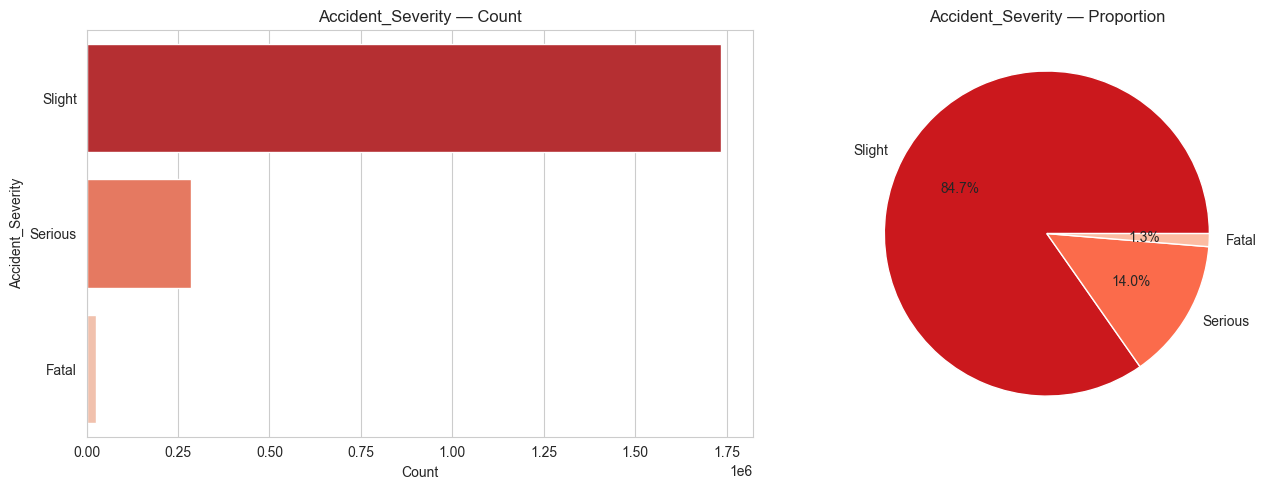

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(y=df_accident[target_col], order=severity_counts.index,
              palette="Reds_r", ax=axes[0])
axes[0].set_title("Accident_Severity — Count")
axes[0].set_xlabel("Count")

axes[1].pie(severity_pct, labels=severity_pct.index, autopct="%1.1f%%",
            colors=sns.color_palette("Reds_r", len(severity_pct)))
axes[1].set_title("Accident_Severity — Proportion")

plt.tight_layout()
plt.show()


## 12. Correlation Analysis

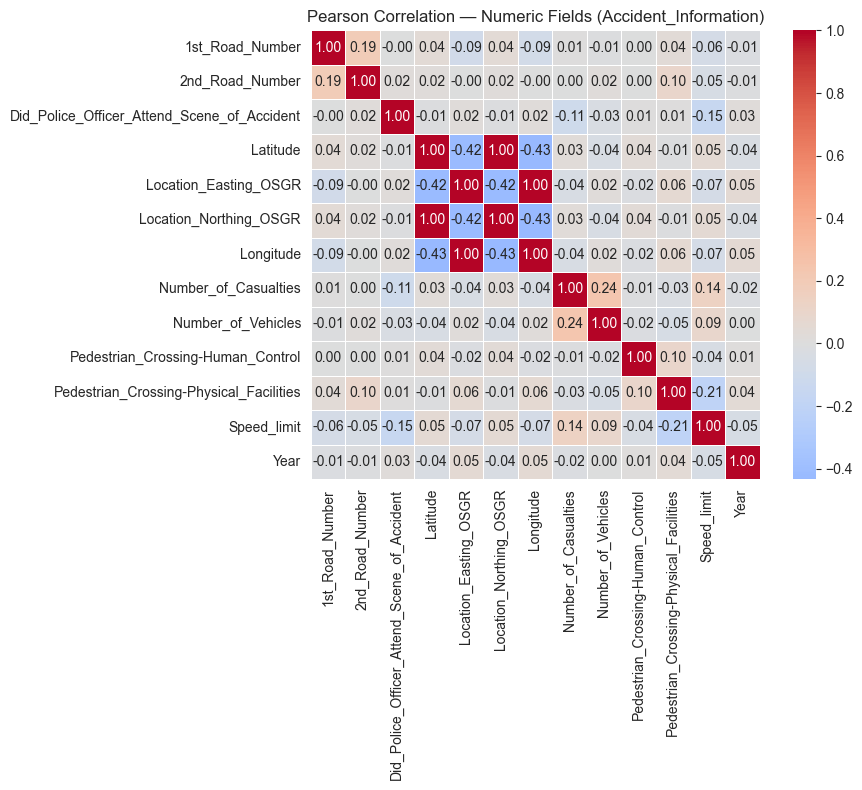

In [48]:
# --- 1. Numeric correlation (Pearson) ---
numeric_cols = df_accident.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_accident[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Pearson Correlation — Numeric Fields (Accident_Information)")
plt.tight_layout()
plt.show()


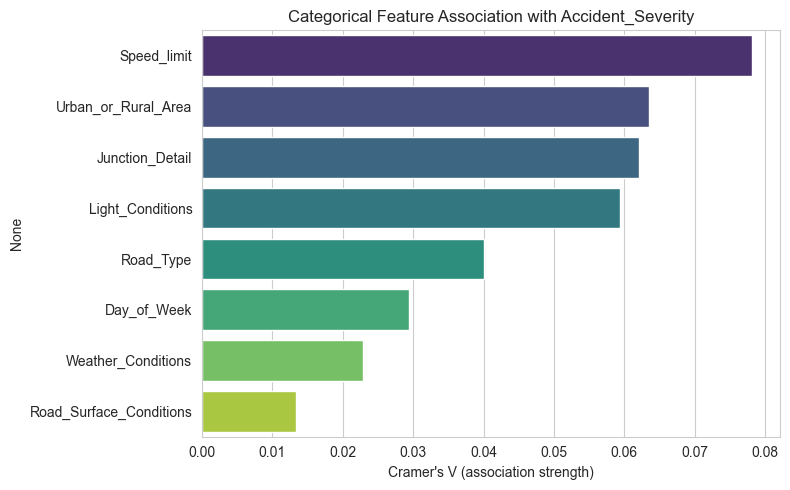

Speed_limit                0.078217
Urban_or_Rural_Area        0.063565
Junction_Detail            0.062046
Light_Conditions           0.059393
Road_Type                  0.040112
Day_of_Week                0.029397
Weather_Conditions         0.022820
Road_Surface_Conditions    0.013366
Name: Cramer's V vs Accident_Severity, dtype: float64

In [49]:
# --- 2. Cramer's V: categorical association with the target ---
def cramers_v(x, y):
    """Cramer's V association strength (0 = no association, 1 = perfect association)
    for two categorical series. Bias-corrected version (Bergsma 2013)."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Candidate categorical fields worth checking against severity — chosen because they're
# domain-plausible severity drivers, not just "every categorical column we have"
candidate_cat_cols = [
    "Weather_Conditions", "Road_Surface_Conditions", "Light_Conditions",
    "Junction_Detail", "Speed_limit", "Urban_or_Rural_Area", "Road_Type",
    "Day_of_Week"
]
candidate_cat_cols = [c for c in candidate_cat_cols if c in df_accident.columns]

cramers_scores = {}
for col in candidate_cat_cols:
    subset = df_accident[[col, target_col]].dropna()
    cramers_scores[col] = cramers_v(subset[col], subset[target_col])

cramers_df = pd.Series(cramers_scores, name="Cramer's V vs Accident_Severity").sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=cramers_df.values, y=cramers_df.index, palette="viridis")
plt.xlabel("Cramer's V (association strength)")
plt.title("Categorical Feature Association with Accident_Severity")
plt.tight_layout()
plt.show()

cramers_df


## 13. Relationship Between Both Datasets

In [50]:
shared_key = "Accident_Index"

accident_keys = set(df_accident[shared_key])
vehicle_keys = set(df_vehicle[shared_key])

print(f"Unique {shared_key} in Accident_Information: {len(accident_keys):,}")
print(f"Unique {shared_key} in Vehicle_Information:  {len(vehicle_keys):,}")
print(f"Keys in both:                    {len(accident_keys & vehicle_keys):,}")
print(f"Keys only in Accident_Information (no vehicle records): {len(accident_keys - vehicle_keys):,}")
print(f"Keys only in Vehicle_Information (orphaned):             {len(vehicle_keys - accident_keys):,}")

vehicles_per_accident = df_vehicle.groupby(shared_key).size()
print(f"\nVehicles per accident — mean: {vehicles_per_accident.mean():.2f}, "
      f"median: {vehicles_per_accident.median():.0f}, max: {vehicles_per_accident.max()}")


Unique Accident_Index in Accident_Information: 2,047,256
Unique Accident_Index in Vehicle_Information:  1,488,981
Keys in both:                    1,389,724
Keys only in Accident_Information (no vehicle records): 657,532
Keys only in Vehicle_Information (orphaned):             99,257

Vehicles per accident — mean: 1.46, median: 1, max: 53


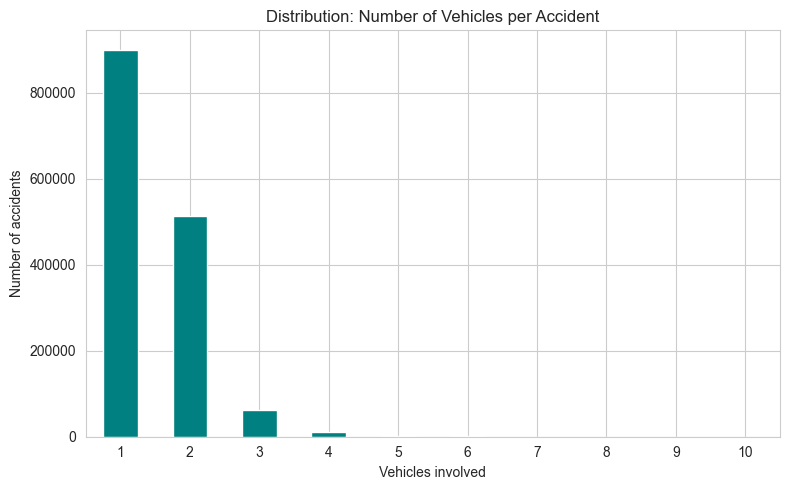

In [51]:
plt.figure(figsize=(8, 5))
vehicles_per_accident.value_counts().sort_index().head(10).plot(kind="bar", color="teal")
plt.title("Distribution: Number of Vehicles per Accident")
plt.xlabel("Vehicles involved")
plt.ylabel("Number of accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. Identify Primary Keys

In [52]:
# Accident_Information: Accident_Index should be the sole primary key
pk_check_accident = df_accident["Accident_Index"].is_unique
print(f"Accident_Information — is 'Accident_Index' unique? {pk_check_accident}")

# Vehicle_Information: composite key expected — Accident_Index + Vehicle_Reference
if "Vehicle_Reference" in df_vehicle.columns:
    pk_check_vehicle = df_vehicle.duplicated(subset=["Accident_Index", "Vehicle_Reference"]).sum()
    print(f"Vehicle_Information — duplicate rows on ('Accident_Index', 'Vehicle_Reference'): {pk_check_vehicle}")
else:
    print("Vehicle_Information — 'Vehicle_Reference' column not found; re-check column names.")


Accident_Information — is 'Accident_Index' unique? True
Vehicle_Information — duplicate rows on ('Accident_Index', 'Vehicle_Reference'): 0


## 15. Identify Candidate Features

In [53]:
feature_assessment = pd.DataFrame({
    "Column": df_accident.columns,
    "Dtype": df_accident.dtypes.astype(str).values,
    "Unique Values": [df_accident[c].nunique() for c in df_accident.columns],
    "Missing %": (df_accident.isnull().sum() / len(df_accident) * 100).round(2).values
})

def classify_column(row):
    col = row["Column"]
    if col in ("Accident_Index",):
        return "Identifier — exclude"
    if col == "Accident_Severity":
        return "TARGET"
    if col in ("Date", "Time"):
        return "Raw datetime — needs feature engineering before use, not a direct feature"
    if row["Unique Values"] == 1:
        return "Zero variance — exclude"
    if row["Unique Values"] > 500:
        return "Very high cardinality — needs grouping/encoding strategy"
    if row["Missing %"] > 50:
        return "Majority missing — exclude unless structurally missing"
    return "Candidate feature"

feature_assessment["Assessment"] = feature_assessment.apply(classify_column, axis=1)
feature_assessment.sort_values("Assessment")


,Column,Dtype,Unique Values,Missing %,Assessment
33,InScotland,object,2,0.00,Candidate feature
22,Pedestrian_Crossing-Human_Control,float64,3,0.14,Candidate feature
23,Pedestrian_Crossing-Physical_Facilities,float64,6,0.17,Candidate feature
32,Year,int64,13,0.00,Candidate feature
15,Local_Authority_(Highway),object,207,0.00,Candidate feature
14,Local_Authority_(District),object,416,0.00,Candidate feature
13,Light_Conditions,object,6,0.00,Candidate feature
24,Police_Force,object,51,0.00,Candidate feature
11,Junction_Detail,object,10,0.00,Candidate feature
21,Number_of_Vehicles,int64,29,0.00,Candidate feature


## 16. Data Quality Report

In [54]:
data_quality_report = {
    "Total accident records": len(df_accident),
    "Total vehicle records": len(df_vehicle),
    "Accident_Information columns with missing values": (df_accident.isnull().sum() > 0).sum(),
    "Vehicle_Information columns with missing values": (df_vehicle.isnull().sum() > 0).sum(),
    "Accident_Information duplicate rows (full)": df_accident.duplicated().sum(),
    "Accident_Information duplicate Accident_Index": df_accident.duplicated(subset=["Accident_Index"]).sum(),
    "Zero-variance columns (Accident_Information)": (unique_accident["Unique Values"] == 1).sum(),
    "High-cardinality columns >50 uniques (Accident_Information)": (unique_accident["Unique Values"] > 50).sum(),
    "Orphaned Vehicle_Information keys (no matching accident)": len(vehicle_keys - accident_keys),
}

dq_df = pd.DataFrame.from_dict(data_quality_report, orient="index", columns=["Value"])
dq_df


,Value
Total accident records,2047256
Total vehicle records,2177205
Accident_Information columns with missing values,16
Vehicle_Information columns with missing values,10
Accident_Information duplicate rows (full),0
Accident_Information duplicate Accident_Index,0
Zero-variance columns (Accident_Information),0
High-cardinality columns >50 uniques (Accident_Information),14
Orphaned Vehicle_Information keys (no matching accident),99257
